Circuit: Quantum Random Bit Generator


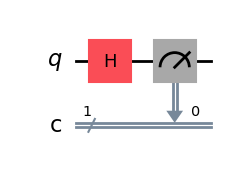


Statistical Hypothesis Testing Results (Alpha = 0.05, Shots = 10000):


,Generator Type,Count (0),Count (1),P-Value,Hypothesis Conclusion
0,Genuine Quantum (QRNG),5010,4990,0.8415,Fail to reject H0 (Uniform)
1,Classical PRNG (Biased),4864,5136,0.0065,Reject H0 (Biased)


In [2]:
# Import the necessary libraries
import numpy as np
import pandas as pd
from scipy.stats import chisquare
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from IPython.display import display

# --- 1. The Quantum Random Number Generator (QRNG) ---
# Create a circuit with 1 qubit and 1 classical bit
qc = QuantumCircuit(1, 1, name="QRNG")

# Apply Hadamard gate to create perfect superposition
qc.h(0)
qc.measure(0, 0)

print("Circuit: Quantum Random Bit Generator")
display(qc.draw(output='mpl', style='iqp'))

# Run the quantum simulation
shots = 10000
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=shots)
quantum_counts = job.result().get_counts(qc)

q_count_0 = quantum_counts.get('0', 0)
q_count_1 = quantum_counts.get('1', 0)

# --- 2. The Classical Pseudo-Random Number Generator (PRNG) ---
# We simulate a classical PRNG with a very slight, hidden bias (e.g., 48% vs 52%)
# This mimics a flawed or non-cryptographic algorithmic generator
np.random.seed(42) # Seed for reproducibility
classical_results = np.random.choice(['0', '1'], size=shots, p=[0.48, 0.52])
c_count_0 = np.sum(classical_results == '0')
c_count_1 = np.sum(classical_results == '1')

# --- 3. Statistical Hypothesis Testing ---
# Null Hypothesis (H0): The distribution is perfectly uniform (5000 zeros, 5000 ones)
expected_counts = [shots / 2, shots / 2]

# Chi-Square test for Quantum Data
chi2_q, p_value_q = chisquare(f_obs=[q_count_0, q_count_1], f_exp=expected_counts)

# Chi-Square test for Classical PRNG Data
chi2_c, p_value_c = chisquare(f_obs=[c_count_0, c_count_1], f_exp=expected_counts)

# Significance level (alpha)
alpha = 0.05

# --- 4. Tabulate and Interpret the Results ---
results_data = [
    {
        "Generator Type": "Genuine Quantum (QRNG)",
        "Count (0)": q_count_0,
        "Count (1)": q_count_1,
        "P-Value": f"{p_value_q:.4f}",
        "Hypothesis Conclusion": "Fail to reject H0 (Uniform)" if p_value_q > alpha else "Reject H0 (Biased)"
    },
    {
        "Generator Type": "Classical PRNG (Biased)",
        "Count (0)": c_count_0,
        "Count (1)": c_count_1,
        "P-Value": f"{p_value_c:.4f}",
        "Hypothesis Conclusion": "Fail to reject H0 (Uniform)" if p_value_c > alpha else "Reject H0 (Biased)"
    }
]

df = pd.DataFrame(results_data)
print(f"\nStatistical Hypothesis Testing Results (Alpha = {alpha}, Shots = {shots}):")
display(df)